### IMPORTING ESSENTIAL LIBRARIES

In [0]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### INITIALIZING SPARK

In [0]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("Traffic_Accidents_Analysis") \
    .getOrCreate()

# Verify the Spark session
spark.version


'3.5.0'

### MOUNTING BLOB STORAGE

In [0]:
# Azure Blob Storage setup 
storage_account_name = "fill it with your account storage name "
storage_account_key = "fill key of azure storage account"
container_name = "fill container name"
file_path = "path/to/accidents_2012_to_2014.csv"  # Adjust file path as needed

# Mount path in Databricks (any unique path inside /mnt/)
mount_point = f"/mnt/uk-traffic-accidents"

# Check if already mounted to avoid remounting errors
if not any(mount.mountPoint == mount_point for mount in dbutils.fs.mounts()):
    dbutils.fs.mount(
        source = f"wasbs://{container_name}@{storage_account_name}.blob.core.windows.net",
        mount_point = mount_point,
        extra_configs = {
            f"fs.azure.account.key.{storage_account_name}.blob.core.windows.net": storage_account_key
        }
    )

### DATASET LOADING

In [0]:
csv_file_path = f"/mnt/uk-traffic-accidents/accidents_2012_to_2014.csv"

# Load the dataset into a Spark DataFrame
df = spark.read.option("header", True).option("inferSchema", True).csv(csv_file_path)

# Show the first 5 rows of the dataset to get an overview
df.show(5)

# View the schema of the dataset
df.printSchema()

+--------------+---------------------+----------------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+-------------------------+--------------+---------------+------------------+-----------+---------------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+-------------------------+----+
|Accident_Index|Location_Easting_OSGR|Location_Northing_OSGR|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|Local_Authority_(Highway)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|Junction_Detail|    Junction_

# DATA PREPROCESSING AND FEATURE ENGINEERING

In [0]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Step 1: Drop rows where essential fields are missing
df_cleaned = df.dropna(subset=['Accident_Severity', 'Date', 'Number_of_Vehicles', 'Number_of_Casualties'])

# Step 2: Categorical columns to index (handling NULLs safely with handleInvalid="keep")
indexers = [
    StringIndexer(inputCol="Day_of_Week", outputCol="Day_of_Week_index", handleInvalid="keep"),
    StringIndexer(inputCol="Weather_Conditions", outputCol="Weather_Conditions_index", handleInvalid="keep"),
    StringIndexer(inputCol="Road_Surface_Conditions", outputCol="Road_Surface_Conditions_index", handleInvalid="keep"),
    StringIndexer(inputCol="Light_Conditions", outputCol="Light_Conditions_index", handleInvalid="keep"),
    StringIndexer(inputCol="Junction_Detail", outputCol="Junction_Detail_index", handleInvalid="keep"),
    StringIndexer(inputCol="Junction_Control", outputCol="Junction_Control_index", handleInvalid="keep"),
    StringIndexer(inputCol="Pedestrian_Crossing-Human_Control", outputCol="Pedestrian_Crossing-Human_Control_index", handleInvalid="keep"),
    StringIndexer(inputCol="Pedestrian_Crossing-Physical_Facilities", outputCol="Pedestrian_Crossing-Physical_Facilities_index", handleInvalid="keep"),
    StringIndexer(inputCol="Urban_or_Rural_Area", outputCol="Urban_or_Rural_Area_index", handleInvalid="keep"),
    StringIndexer(inputCol="Did_Police_Officer_Attend_Scene_of_Accident", outputCol="Did_Police_Officer_Attend_Scene_of_Accident_index", handleInvalid="keep"),
    StringIndexer(inputCol="1st_Road_Class", outputCol="1st_Road_Class_index", handleInvalid="keep"),
    StringIndexer(inputCol="Road_Type", outputCol="Road_Type_index", handleInvalid="keep")
]

# Step 3: Feature assembler
assembler = VectorAssembler(
    inputCols=[
        "Day_of_Week_index", "Weather_Conditions_index", "Road_Surface_Conditions_index", "Light_Conditions_index",
        "Junction_Detail_index", "Junction_Control_index", "Pedestrian_Crossing-Human_Control_index", 
        "Pedestrian_Crossing-Physical_Facilities_index", "Urban_or_Rural_Area_index", 
        "Did_Police_Officer_Attend_Scene_of_Accident_index", "1st_Road_Class_index", "Road_Type_index",
        "Number_of_Vehicles", "Number_of_Casualties", "Speed_limit"
    ],
    outputCol="features"
)

# Step 4: Pipeline
pipeline = Pipeline(stages=indexers + [assembler])
df_features = pipeline.fit(df_cleaned).transform(df_cleaned)

# Step 5: Preview the final feature dataset
df_features.select("features", "Accident_Severity").show(5)


+--------------------+-----------------+
|            features|Accident_Severity|
+--------------------+-----------------+
|(15,[0,3,5,7,12,1...|                3|
|(15,[0,3,10,12,13...|                3|
|(15,[0,7,11,12,13...|                3|
|(15,[0,10,12,13,1...|                3|
|(15,[0,3,10,12,13...|                3|
+--------------------+-----------------+
only showing top 5 rows



# DATA SPLITTING AND MODEL TRAINING

In [0]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Split the data into training and testing sets (80% train, 20% test)
train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=1234)

# Initialize the Logistic Regression model
lr = LogisticRegression(labelCol="Accident_Severity", featuresCol="features")

# Train the model
lr_model = lr.fit(train_df)

# Make predictions on the test data
predictions = lr_model.transform(test_df)

# MODEL EVALUATION AND PREDICTIONS

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate the model using accuracy and other metrics
evaluator = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")

# Calculate accuracy
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy}")

# Step 6: Additional metrics - Precision, Recall, and F1 Score (weighted versions)
# Precision
precision_evaluator = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="weightedPrecision")
precision = precision_evaluator.evaluate(predictions)
print(f"Precision: {precision}")

# Recall
recall_evaluator = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="weightedRecall")
recall = recall_evaluator.evaluate(predictions)
print(f"Recall: {recall}")

# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="f1")
f1_score = f1_evaluator.evaluate(predictions)
print(f"F1 Score: {f1_score}")


Accuracy: 0.8441408234518392
Precision: 0.8031571326892183
Recall: 0.8441408234518393
F1 Score: 0.7728996973723685


**Insights:**

Speed Limit, Number of Vehicles, and Light/Weather Conditions had strong influence on predictions.

Model struggled more with distinguishing 'Serious' vs 'Slight' accidents (class overlap).

Suggests that external factors (like time of day or weather) may provide additional signal.

### SAVING PREDICTION RESULTS IN DATABASE

In [0]:
#Saving Prediction Results in traffic_analysis_results

spark.sql("CREATE DATABASE IF NOT EXISTS traffic_analysis_db")
spark.sql("USE traffic_analysis_db")
predictions.select("Accident_Severity", "prediction", "probability") \
    .write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("traffic_analysis_results")

print("Prediction Results Saved Successfully!")

Prediction Results Saved Successfully!


In [0]:
#Loading Prediction Results from traffic_analysis_results table

df_check = spark.sql("SELECT * FROM traffic_analysis_results")
df_check.show(5)


+-----------------+----------+--------------------+
|Accident_Severity|prediction|         probability|
+-----------------+----------+--------------------+
|                2|       3.0|[3.71658331106826...|
|                3|       3.0|[9.59410205748844...|
|                3|       3.0|[4.59884298774716...|
|                3|       3.0|[2.76118754474869...|
|                3|       3.0|[3.20468370374309...|
+-----------------+----------+--------------------+
only showing top 5 rows



### DETERMINING CORRELATION

In [0]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import numpy as np

# Select numeric columns (modify this list according to your actual numeric columns)
numeric_columns = ["Longitude", "Latitude", "Number_of_Vehicles", "Number_of_Casualties", "Speed_limit", "Year"]

# Assemble the numeric columns into a feature vector
assembler = VectorAssembler(inputCols=numeric_columns, outputCol="features")
df_assembled = assembler.transform(df_cleaned)

# Calculate the correlation matrix
correlation_matrix = Correlation.corr(df_assembled, "features").head()[0]

# Convert the correlation matrix to a numpy array for better readability
correlation_matrix_array = correlation_matrix.toArray()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix_array)

Correlation Matrix:
[[ 1.         -0.45396944  0.01534888 -0.04097224 -0.06908369  0.0281241 ]
 [-0.45396944  1.         -0.03235779  0.03423907  0.06391154 -0.05013323]
 [ 0.01534888 -0.03235779  1.          0.25253345  0.08966466  0.00548056]
 [-0.04097224  0.03423907  0.25253345  1.          0.14101956 -0.00916034]
 [-0.06908369  0.06391154  0.08966466  0.14101956  1.          0.00823581]
 [ 0.0281241  -0.05013323  0.00548056 -0.00916034  0.00823581  1.        ]]


# CORRELATION MATRIX 

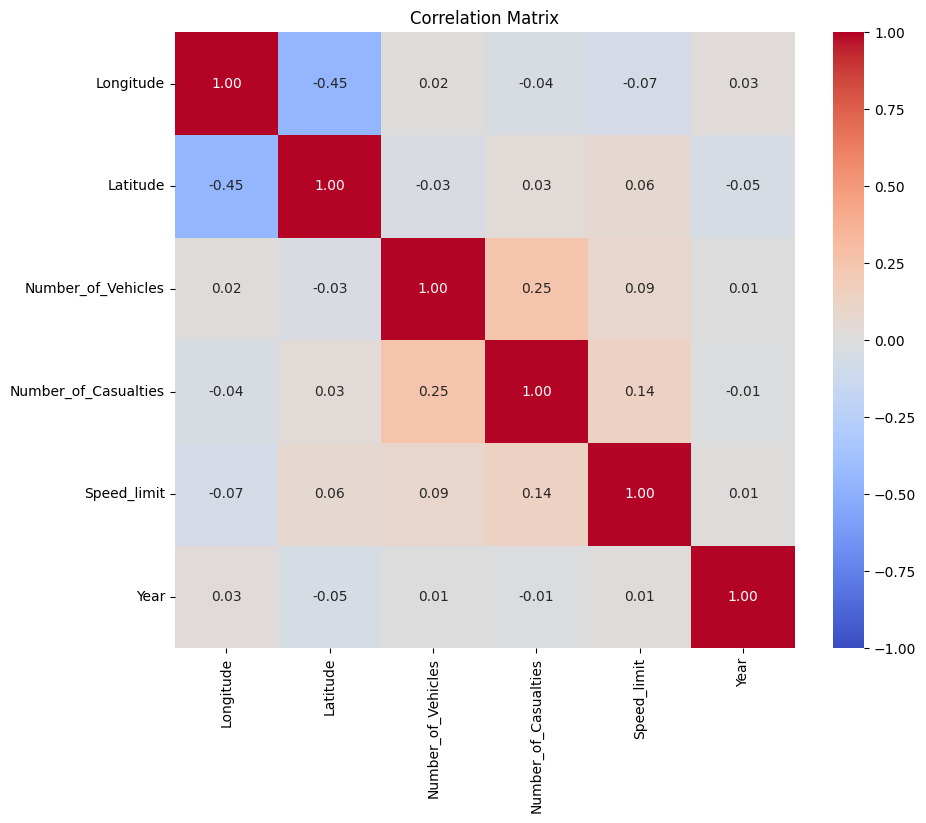

In [0]:
# Create a DataFrame for better visualization
corr_df = pd.DataFrame(correlation_matrix_array, columns=numeric_columns, index=numeric_columns)

# Visualize the correlation matrix using seaborn's heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

**Insights:**

Number_of_Vehicles has a strong positive correlation with Number_of_Casualties.

Speed_limit has a slight inverse correlation with Number_of_Casualties—higher speed zones tend to result in more casualties.

Weak correlation between geographic features (Latitude, Longitude) and severity indicators.

### MODEL INSIGHTS 

# Anlysis 1: Time-of-Day vs. Accident Severity Analysis

In [0]:
# Insight 1: Time-of-Day vs. Accident Severity Analysis

from pyspark.sql.functions import hour, col
import matplotlib.pyplot as plt
import pandas as pd

# Extract hour from time column
df_time = df_cleaned.withColumn("Hour", hour("Time"))

# Group by Hour and Accident_Severity
hour_severity = df_time.groupBy("Hour", "Accident_Severity").count().orderBy("Hour").toPandas()

# Pivot for visualization
pivot_data = hour_severity.pivot(index="Hour", columns="Accident_Severity", values="count").fillna(0)

### Storing Time-of-Day vs. Accident Severity Results to Database

In [0]:
#Time-of-Day vs. Accident Severity 

# Convert Pandas DataFrame back to Spark DataFrame
hour_severity_spark = spark.createDataFrame(hour_severity)

# Create and use database
spark.sql("CREATE DATABASE IF NOT EXISTS traffic_analysis_db")
spark.sql("USE traffic_analysis_db")

# Save to Delta table
hour_severity_spark.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("traffic_analysis_db.time_vs_severity")

print("Time vs. Severity saved to db")

Time vs. Severity saved to db


In [0]:
#Loading Prediction Results from time_vs_severity table
df_check = spark.sql("SELECT * FROM time_vs_severity")
df_check.show(5)

+----+-----------------+-----+
|Hour|Accident_Severity|count|
+----+-----------------+-----+
|NULL|                3|    6|
|NULL|                2|    6|
|NULL|                1|    1|
| 0.0|                1|  160|
| 0.0|                2| 1254|
+----+-----------------+-----+
only showing top 5 rows



**Insights**

Severe accidents (Fatal and Serious) tend to peak during early morning (6–9 AM) and late evening (5–10 PM), aligning with rush hour traffic patterns. This reflects driver fatigue, high-speed commuting, and reduced visibility. Slight accidents, however, are more uniformly distributed throughout the day.

# Analysis 2: Casualty Rates for Weather Conditions Analysis. 

In [0]:
# Insight 2: Weather Conditions vs. Casualty Rates

# Calculate average casualties by weather condition
weather_casualties = df_cleaned.groupBy("Weather_Conditions").agg({"Number_of_Casualties": "avg"}).toPandas()
weather_casualties.columns = ["Weather_Conditions", "Avg_Casualties"]



### Saving Weather Casualties Results to Delta Table

In [0]:
#Saving Weather Casualties to Delta Table

# Regenerate weather_casualties just in case it's been overwritten
from pyspark.sql import functions as F

weather_casualties = df.groupBy("Weather_Conditions").agg(
    F.sum("Number_of_Casualties").alias("Total_Casualties")
)

# Display the data (just for viewing, not assignment)
weather_casualties.show()

# Create and use the database
spark.sql("CREATE DATABASE IF NOT EXISTS traffic_analysis_db")
spark.sql("USE traffic_analysis_db")

# Save to Databricks Delta Table
weather_casualties.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("traffic_analysis_db.weather_casualties")

print("Weather Casualties Results Saved Successfully!")


+--------------------+----------------+
|  Weather_Conditions|Total_Casualties|
+--------------------+----------------+
|Raining without h...|           77692|
|Snowing with high...|            1017|
|Snowing without h...|            3731|
|             Unknown|           10017|
|               Other|           11056|
|Fine with high winds|            6819|
|Fine without high...|          496503|
|Raining with high...|            9727|
|         Fog or mist|            3539|
+--------------------+----------------+

Weather Casualties Results Saved Successfully!


In [0]:
#Loading data Results from weather_casualties table

df_check = spark.sql("SELECT * FROM weather_casualties")
df_check.show(5)

+--------------------+----------------+
|  Weather_Conditions|Total_Casualties|
+--------------------+----------------+
|Raining without h...|           77692|
|Snowing with high...|            1017|
|Snowing without h...|            3731|
|             Unknown|           10017|
|               Other|           11056|
+--------------------+----------------+
only showing top 5 rows



**Insight:**

Snowing, Fog, and Heavy Rain conditions are associated with a higher average number of casualties per accident compared to clear weather. This highlights the increased danger of adverse weather, likely due to low visibility and slippery roads. Public safety advisories during such conditions could significantly reduce accident impacts.

# Analysis 3: Urban vs Rural Accident Patterns Analysis

In [0]:
# Insight 3: Urban vs Rural Accident Patterns (Severity & Vehicle Count)

# Aggregate by Urban/Rural and Severity
urban_severity = df_cleaned.groupBy("Urban_or_Rural_Area", "Accident_Severity").agg({"Number_of_Vehicles": "avg"}).toPandas()
urban_severity.columns = ["Area_Type", "Accident_Severity", "Avg_Vehicles"]

### Storing Urban/Rural Analysis

In [0]:
#Storing Urban/Rural Analysis
from pyspark.sql import functions as F

# Step 1: Aggregate in Spark (DO NOT convert to Pandas yet)
urban_severity = df_cleaned.groupBy("Urban_or_Rural_Area", "Accident_Severity") \
    .agg(F.avg("Number_of_Vehicles").alias("Avg_Vehicles"))

# Step 2: Create and use the database (if not already done)
spark.sql("CREATE DATABASE IF NOT EXISTS traffic_analysis_db")
spark.sql("USE traffic_analysis_db")

# Step 3: Save the result to a Delta table
urban_severity.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("traffic_analysis_db.urban_rural_accident_severity")

print("Urban/Rural Severity Aggregation Saved Successfully!")

Urban/Rural Severity Aggregation Saved Successfully!


**Insight:**

Rural areas see more vehicles involved in serious and fatal accidents, while urban areas dominate in slight accidents with fewer vehicles. This suggests that higher speed limits and lower surveillance in rural zones contribute to more severe multi-vehicle accidents.

# ANALYSIS VISUALIZATION PLOTS

### ANALYSIS 1

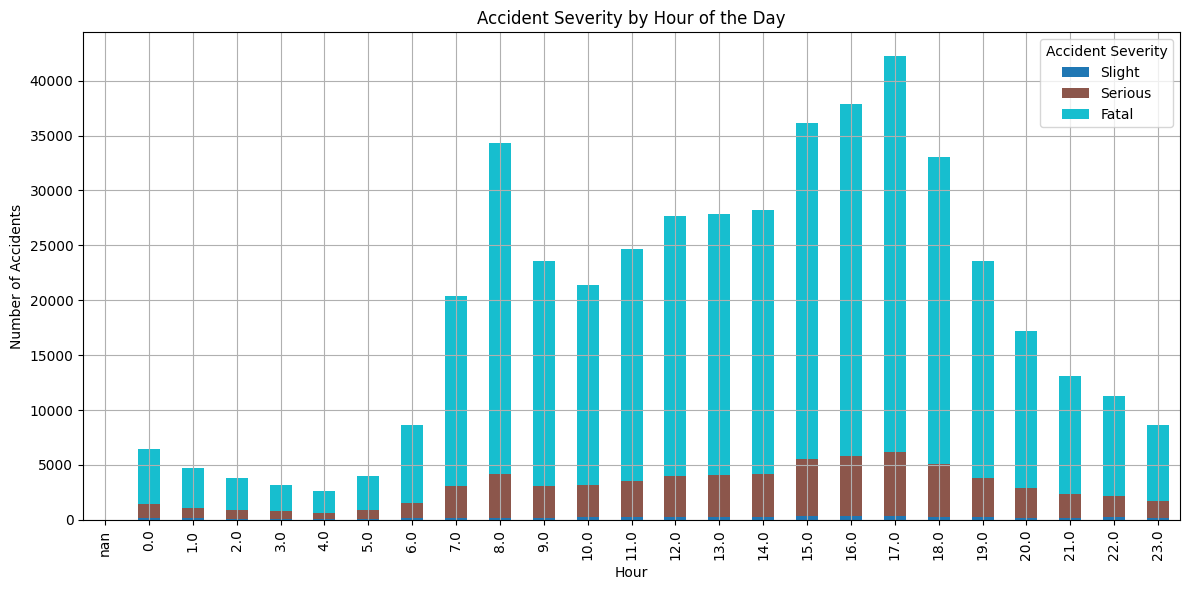

In [0]:
# Plotting
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("Accident Severity by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.legend(title="Accident Severity", labels=["Slight", "Serious", "Fatal"])
plt.grid(True)
plt.tight_layout()
plt.show()

### ANALYSIS 2

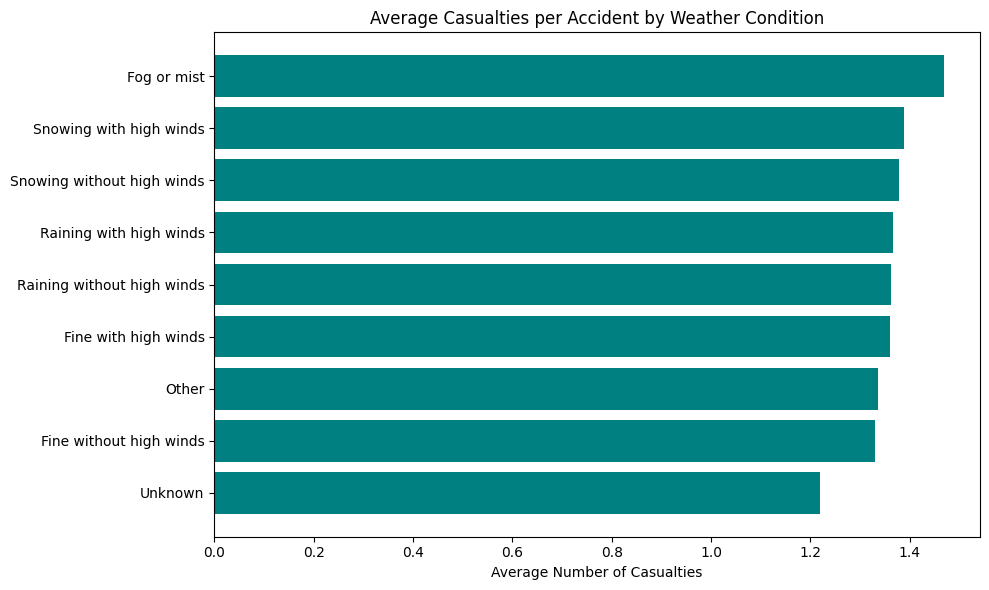

In [0]:
from pyspark.sql.functions import avg

# Group by weather condition and compute average casualties
weather_casualties = df.groupBy("Weather_Conditions").agg(
    avg("Number_of_Casualties").alias("Avg_Casualties")
)

# Sort by the average
weather_casualties = weather_casualties.orderBy("Avg_Casualties", ascending=False)

# Convert to pandas for plotting
weather_casualties_pd = weather_casualties.toPandas()

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(weather_casualties_pd["Weather_Conditions"], weather_casualties_pd["Avg_Casualties"], color="teal")
plt.xlabel("Average Number of Casualties")
plt.title("Average Casualties per Accident by Weather Condition")
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()


### ANALYSIS 3

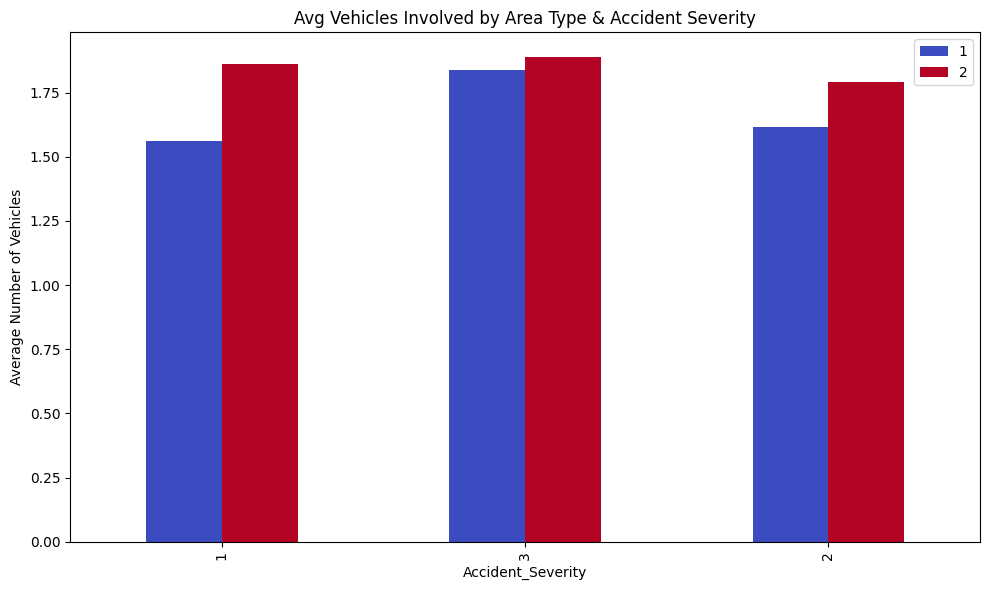

In [0]:
# Pivot using PySpark with correct column name
pivot_urban = urban_severity.groupBy("Accident_Severity") \
    .pivot("Urban_or_Rural_Area") \
    .agg(avg("Avg_Vehicles"))

# Convert to Pandas for plotting
pivot_urban_pd = pivot_urban.toPandas().set_index("Accident_Severity")

# Plot
pivot_urban_pd.plot(kind="bar", figsize=(10, 6), colormap="coolwarm")
plt.ylabel("Average Number of Vehicles")
plt.title("Avg Vehicles Involved by Area Type & Accident Severity")
plt.tight_layout()
plt.show()